# Linear Regression Implementation

This notebook contains the code for implementation of linear regression on a given dataset in CSV format. The links to the resources used, what the code does etc are mentioned along with the pieces of code in each section.

## Notebook Structure

The notebook will be following a well-defined structure to make things easier for the reader. The structure followed is given below -
### Section Name
1. References (Links)
2. Code (One or more cells)
3. Write-Up (Inferences from outputs of that section)

# 1. Dataset Loading

## References -

1. Video: https://youtu.be/vmEHCJofslg?si=79HTyKXMa7iMEr4k
    - I had watched this video earlier during another workshop and understood how pandas works
2. Article: https://pandas.pydata.org/docs/getting_started/intro_tutorials/01_table_oriented.html
    - Most of my pandas-related learning for this task was from here

## Code

In [1]:
#First we import the most important module - pandas
import pandas as pd

#Then we load the dataset (Standard syntax)
df = pd.read_csv("linear_regression_dataset.csv")

In [2]:
#Now, we try to understand the dataset

#First, I'm going to see the first few rows of the dataset to understand the nature of data
df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,target
0,-0.885348,-0.318384,-0.681882,-0.525339,-0.173139,-0.049100,-0.730028,0.268017,0.844092,0.086956,13.812971
1,0.035805,0.914707,-0.779525,0.765028,0.616923,-0.072274,-0.857656,0.717170,-0.900923,-0.332585,21.425618
2,-0.236609,0.480134,0.653774,0.476751,-0.574669,0.368244,0.770633,0.816649,0.071216,-0.325806,-9.472456
3,0.348254,0.887513,-0.530695,0.089664,0.440671,0.551195,-0.533984,-0.192555,0.525992,-0.941095,7.606811
4,0.208330,-0.780880,0.413807,0.672348,0.202937,-0.898062,-0.744548,-0.823112,-0.303068,-0.614794,0.307696


In [3]:
#Now that we've seen how the first few rows look, I'm doing to describe the data and check the types for each 
#(Although it's clear from the above output, it just makes things cleaner)

print(df.dtypes)
df.describe()

x0        float64
x1        float64
x2        float64
x3        float64
x4        float64
x5        float64
x6        float64
x7        float64
x8        float64
x9        float64
target    float64
dtype: object


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,target
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.066993,0.019975,0.041093,-0.059924,0.037511,0.010189,-0.055190,0.059748,0.001512,-0.010271,4.119904
std,0.582216,0.578704,0.592574,0.600519,0.583696,0.563888,0.566449,0.548809,0.568715,0.582101,9.546344
min,-0.990045,-0.995725,-0.984495,-0.996218,-0.998647,-0.999469,-0.997808,-0.986700,-0.995511,-0.998175,-16.855749
25%,-0.375321,-0.442177,-0.462756,-0.612056,-0.467282,-0.395592,-0.548815,-0.366555,-0.484113,-0.502621,-3.354981
50%,0.063760,0.050484,0.093862,-0.027408,0.084419,-0.029009,-0.082588,0.074044,0.051957,-0.060621,4.071498
75%,0.600529,0.495501,0.552246,0.476257,0.575316,0.514831,0.381936,0.565957,0.492636,0.541512,11.489982
max,0.995952,0.990795,0.999734,0.992743,0.982925,0.990089,0.996948,0.993871,0.990693,0.999057,28.797352


In [4]:
#And now I'm going to analyse the shape and get some information regarding the dataset

print(df.shape, end="\n\n") #The backslash n is just for formatting
df.info()

(250, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      250 non-null    float64
 1   x1      250 non-null    float64
 2   x2      250 non-null    float64
 3   x3      250 non-null    float64
 4   x4      250 non-null    float64
 5   x5      250 non-null    float64
 6   x6      250 non-null    float64
 7   x7      250 non-null    float64
 8   x8      250 non-null    float64
 9   x9      250 non-null    float64
 10  target  250 non-null    float64
dtypes: float64(11)
memory usage: 21.6 KB


## Write-Up

- Dataset contains 250 samples
- 10 feature columns
- 1 target column
- No missing values

# 2. Data Preparation

## References

1. Video: https://youtu.be/QUT1VHiLmmI?si=U0yFGrCBxPt7NYYH
    - I'd watched this video originally to understand NumPy
2. Article: https://numpy.org/doc/stable/user/quickstart.html
    - The main article I've used for quick references of NumPy syntaxes etc
(NumPy is not used in this section but is used in further sections. I've included these since NumPy is being imported, and references to other parts are in the previous section itself.)

## Code

In [5]:
import numpy as np

X = df.drop("target", axis=1).values
y = df["target"].values

In [6]:
print(X.shape)
print(y.shape)

(250, 10)
(250,)


## Write-Up

- Features and target get separated.
- X stores input features.
- y stores target values.

# 3. Adding Bias Columns

## References

1. Article: https://numpy.org/doc/stable/reference/generated/numpy.hstack.html
    - After making a ones array for the bias terms, just horizontally stack it using this function

## Code

In [7]:
ones = np.ones((X.shape[0], 1))

In [8]:
X = np.hstack((ones, X))
print(X.shape)

(250, 11)


## Write-Up

- Added a column of ones to incorporate the intercept term into matrix calculations.

# 4. Training the Model using Pseudo-inverse

## References

1. Video: https://youtu.be/sdzzMVhmla4?si=VIv0z9dcaP9ce_mb
    - I used this for a deeper intuiton on pseudo-inverse.
2. Article: https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html
    - Used this to understand the numpy.linalg.pinv part and what it does.

## Code

In [9]:
theta = np.linalg.pinv(X) @ y

print(theta)

[ 4.15503584 -1.77041197  1.96372233 -7.3708616   3.0539869   5.332077
 -1.65959664 -6.91759605  1.05354336  1.18243787  9.68448205]


## Write-Up

- Implemented Pseudo Inverse using NumPy.

# 5. Generating Predictions using Pseudo Inverse

## References

- None really, this part is pretty straight-forward.

## Code

In [10]:
y_pred = X @ theta

print(y_pred[:10])

[14.8498345  19.78175448 -9.06301901  5.90071184  1.79946762 -5.74554626
 19.76304996 -0.68943913 19.82987771  1.54391024]


## Write-Up

- Generated predicted y values using learned model parameters.

# 6. Evaluation of Pseudo Inverse model

## References

1. Video: https://youtu.be/2AQKmw14mHM?si=ZINLr0AIp5gajkDo
    - Apart from MSE and RMSE, I learnt that even R^2 is an important way to understand how well the model performs.

## Code

In [11]:
#Computing MSE
mse = np.mean((y-y_pred)**2)

#Computing RMSE
rmse = np.sqrt(mse)

#Computing R-squared
ss_res = np.sum((y-y_pred)**2)
ss_tot = np.sum((y-np.mean(y))**2)

r2 = 1 - (ss_res/ss_tot)

#Print out the evaluation metrics
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R-squared: ", r2)

MSE:  0.7955440727013385
RMSE:  0.891932773644594
R-squared:  0.9912354281996731


## Write-Up

- Computing MSE, RMSE and R-squared score.
- Discussed model performance based on obtained values.

# 7. Linear Regression using Gradient-Descent

## References

1. Article: https://realpython.com/gradient-descent-algorithm-python/
    - Parts of this Article helped me implement the algorithm

## Code

In [12]:
#Initialising weights
#The theta obtained from here we'll call it theta_gd
theta_gd = np.zeros(X.shape[1])

learning_rate = 0.01
epochs = 400

n = len(y)

In [13]:
#Training loop
cost_history = []

for epoch in range(epochs):
    predictions = X @ theta_gd
    errors = predictions - y
    gradient = (2/n)* X.T @ errors
    theta_gd = theta_gd - learning_rate*gradient
    cost = np.mean(errors**2)
    cost_history.append(cost)

## Write-Up

- Gradient Decent is implemented for 400 epochs.
- Learning rate is set to 0.01 which can be tuned if things don't work well.

# 8. Visualising Convergence

## References

Matplotlib documentation for syntax.

## Code

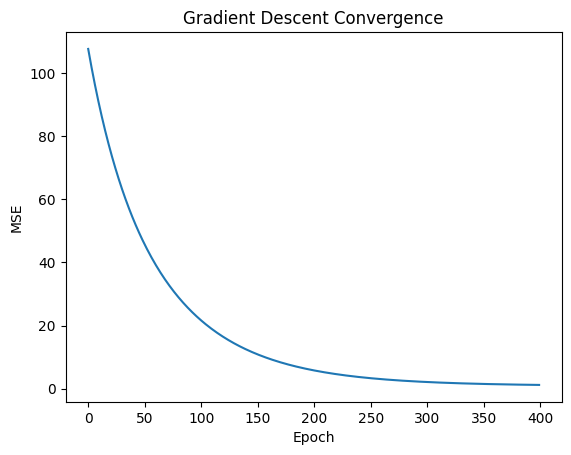

In [14]:
import matplotlib.pyplot as plt

plt.plot(cost_history)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Gradient Descent Convergence")

plt.show()

## Write-Up

- We can see how the error is getting minimised with epochs.
- Clean rate of convergence is observed within 400 epochs.

# 9. Predictions and Evaluation of Gradient Descent Model

## References

None for this section

## Code

In [15]:
# Predictions
y_pred_gd = X @ theta_gd

#Evaluation
#Computing MSE
mse_gd = np.mean((y-y_pred_gd)**2)

#Computing RMSE
rmse_gd = np.sqrt(mse_gd)

#Computing R-squared
ss_res_gd = np.sum((y-y_pred_gd)**2)
ss_tot_gd = np.sum((y-np.mean(y))**2)

r2_gd = 1 - (ss_res_gd/ss_tot_gd)

#Print out the evaluation metrics
print("MSE: ", mse_gd)
print("RMSE: ", rmse_gd)
print("R-squared: ", r2_gd)

MSE:  1.1496375542864816
RMSE:  1.0722115249737254
R-squared:  0.9873343523826633


## Write-Up

- Here we can evaluate the model using different metrics, and this shows that the model is efficient.

# 10. Visualisation

## References

1. Video: https://youtu.be/DAQNHzOcO5A?si=IaXNCKalW-mjqNer
    - Not the entire video, but parts of them helped understand plotting although most of it is already known.
2. Article: Matplotlib documentation for certain syntaces

## Code

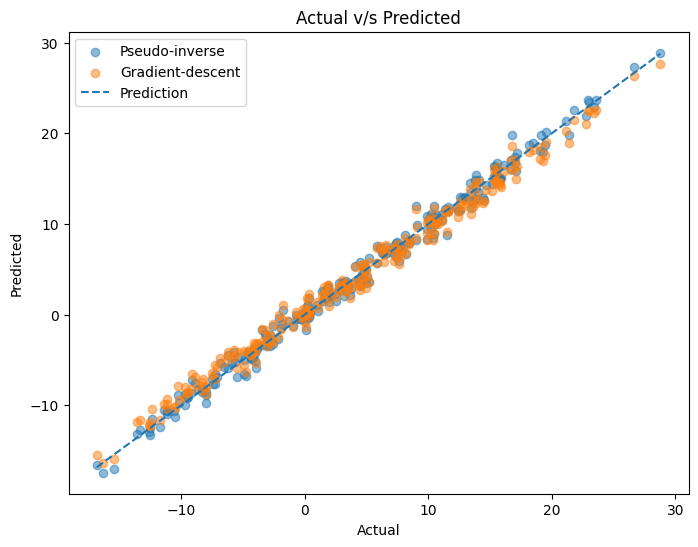

In [16]:
plt.figure(figsize = (8,6))

#Set alphas to 0.5 to control opacity
plt.scatter(y, y_pred, label="Pseudo-inverse", alpha = 0.5)
plt.scatter(y, y_pred_gd, label="Gradient-descent", alpha = 0.5)

plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--", label="Prediction")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual v/s Predicted")
plt.legend()
plt.show()

## Write-Up

- Here the actual values and predicted values are compared for both models.
- We can see that the points are extremely close to the ideal line, so the pinv model is doing a good job :)
- The gradient descent points are slightly off but still close enough (we knew it'd happen comparing R^2 values itself)

# 11. Conclusion -

## Code

In [17]:
#Let's compare the two models and check for higher accuracy
print("Pseudo Inverse MSE :", mse)
print("Gradient Descent MSE :", mse_gd)

print("Pseudo Inverse RMSE :", rmse)
print("Gradient Descent RMSE :", rmse_gd)

print("Pseudo Inverse R-squared :", r2)
print("Gradient Descent R-squared :", r2_gd)

Pseudo Inverse MSE : 0.7955440727013385
Gradient Descent MSE : 1.1496375542864816
Pseudo Inverse RMSE : 0.891932773644594
Gradient Descent RMSE : 1.0722115249737254
Pseudo Inverse R-squared : 0.9912354281996731
Gradient Descent R-squared : 0.9873343523826633


## Write-Up

- Linear Regression was implemented and visualised using various modules.
- Pseudo-inverse method was used for calculating (Projections or Least-squares problem) and solutiongs were computed using NumPy.
- Gradient Descent was also implemented succesfully.
- Generated predictions using both models and evaluated model performance.
- Finally we compared and even visualised the prediction quality of both models (not the exact X-y plot thought because that'd lead to a hyperplane)